<a href="https://colab.research.google.com/github/AugustoSSerpa/hands_on_spr_2026/blob/main/hands_on_spr_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩻 Foundation Models para Radiologia: ImageNet vs. Domínio Clínico
## Hands-on Vibe Coding — Sociedade Paulista de Radiologia 2026

---

### A Pergunta Central

Um modelo treinado em fotos do cotidiano (gatos, carros, 1.000 classes) tem o mesmo valor como extrator de características radiológicas que um modelo treinado em **880 mil raios-X de tórax**?

Neste hands-on você vai responder isso experimentalmente:

| Extrator | Pré-treinamento | O que aprendeu |
|---|---|---|
| **EfficientNetB0** | ImageNet (1,28M fotos naturais) | Bordas, texturas, formas gerais |
| **RAD-DINO** | 880K+ raios-X de tórax (Microsoft, 2024) | Opacidades, consolidações, textura pulmonar |

**Experimento:** congele ambos os backbones → treine a **mesma cabeça classificadora** em cada → compare o t-SNE dos embeddings e as métricas no conjunto de teste.

---

### Dataset: PneumoniaMNIST

- **1.000 imagens** de raio-X de tórax (64×64 pixels, subsample reproduzível)
- **2 classes:** Normal vs Pneumonia Bacteriana/Viral
- Download automático via `pip install medmnist` — sem login, sem cadastro
- Fonte: Kermany et al., *Cell* 2018 | Licença: CC BY 4.0

---

### Como usar este notebook

1. **Ative o GPU T4:** Menu `Ambiente de execução` → `Alterar tipo de hardware` → T4 GPU → Salvar → Reconectar
2. Para **cada Prompt Card**, copie o prompt e cole no **Gemini** (ícone ✦ ou `Ctrl+Shift+I`)
3. O Gemini irá gerara um código na célula que corresponde a cada prompt, aí é só executar
4. Tudo é construído via Gemini — não há células pré-preenchidas

---

## Prompt Card 0: Setup e Preparação

In [118]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# 1. Instalação de bibliotecas necessárias
!pip install medmnist timm -q

import medmnist
from medmnist import INFO, Evaluator

# 2. Definição de SEED para reproducibilidade
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 3. Configuração do DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rodando no dispositivo: {DEVICE}")

# 4. Funções auxiliares
def get_embeddings(model, loader, device):
    """Extrai embeddings do backbone do modelo."""
    model.eval()
    embeddings = []
    labels = []
    with torch.no_grad():
        for inputs, targets in tqdm(loader, desc="Extraindo características"):
            inputs = inputs.to(device)
            features = model(inputs)
            embeddings.append(features.cpu().numpy())
            labels.append(targets.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

print("Setup concluído com sucesso.")

Rodando no dispositivo: cuda
Setup concluído com sucesso.


## Prompt Card 1: Carregar e Visualizar o Dataset

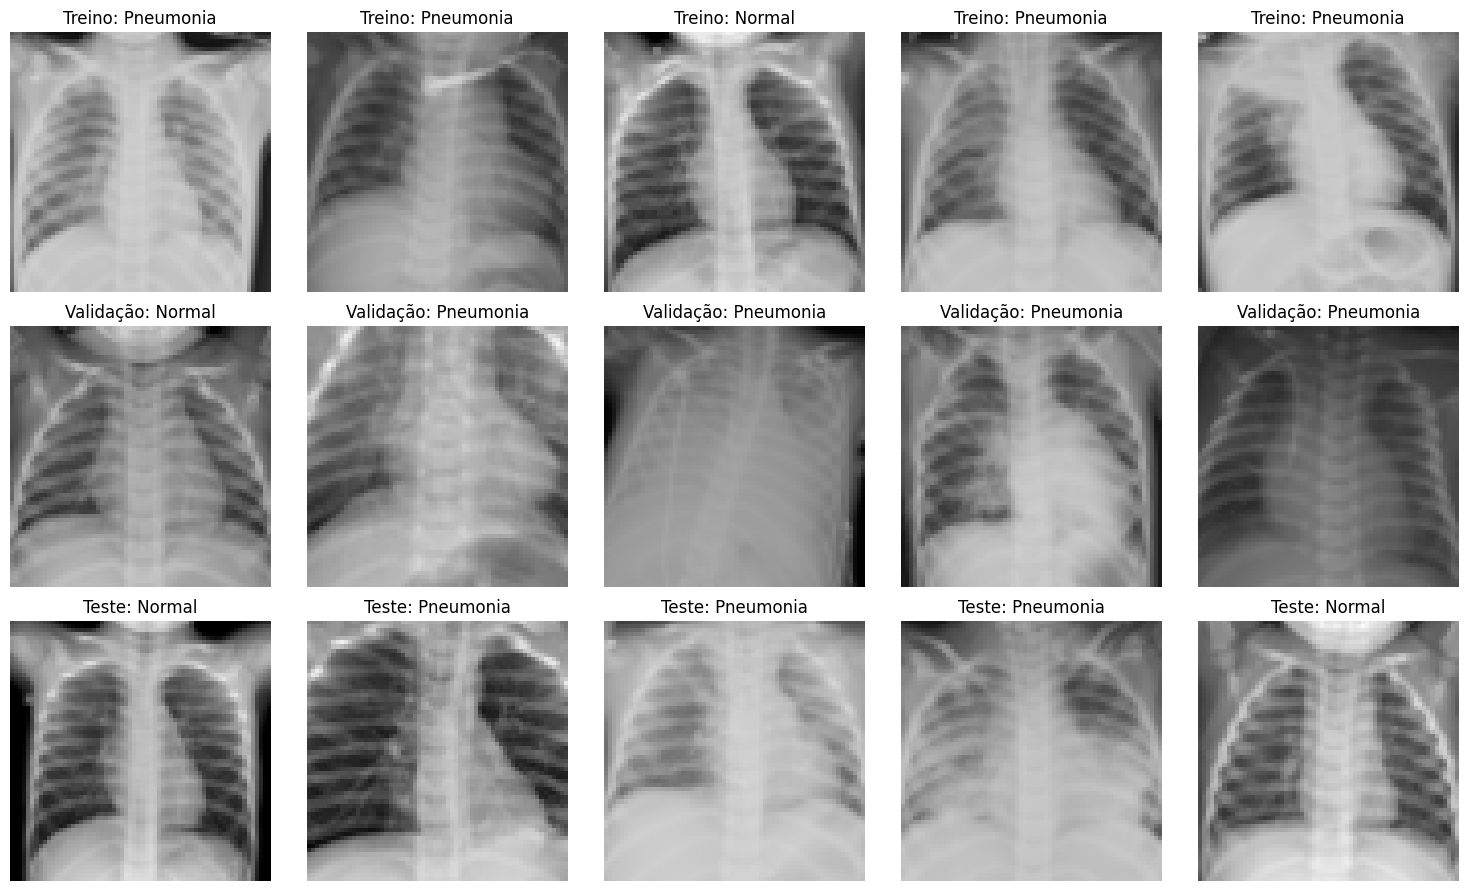

Dataset carregado. Treino: (800, 64, 64, 3), Val: (100, 64, 64, 3), Teste: (100, 64, 64, 3)


In [119]:
import numpy as np
import matplotlib.pyplot as plt
import medmnist
from medmnist import INFO
from torch.utils.data import Subset

# 1. Configurações do Dataset
data_flag = 'pneumoniamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# 2. Carregar o dataset completo (resolução 64x64)
# Note: medmnist permite carregar versões de 64x64 via parâmetro size
full_train = DataClass(split='train', download=True, size=64)
full_val = DataClass(split='val', download=True, size=64)
full_test = DataClass(split='test', download=True, size=64)

# 3. Concatenar e criar splits personalizados (800/100/100 = 1000 imagens)
all_imgs = np.concatenate([full_train.imgs, full_val.imgs, full_test.imgs], axis=0)
all_labels = np.concatenate([full_train.labels, full_val.labels, full_test.labels], axis=0)

# Garantir que pegamos exatamente 1000 imagens de forma determinística
indices = list(range(1000))
random.seed(SEED)
random.shuffle(indices)

train_idx = indices[:800]
val_idx = indices[800:900]
test_idx = indices[900:1000]

# 4. Função de pré-processamento (0-1, 3 canais)
def preprocess_subset(imgs, labels):
    # Normalizar 0-1
    imgs = imgs.astype(np.float32) / 255.0
    # Converter Gray para RGB (3 canais)
    if imgs.ndim == 3:
        imgs = np.stack([imgs]*3, axis=-1)
    return imgs, labels

x_train, y_train = preprocess_subset(all_imgs[train_idx], all_labels[train_idx])
x_val, y_val = preprocess_subset(all_imgs[val_idx], all_labels[val_idx])
x_test, y_test = preprocess_subset(all_imgs[test_idx], all_labels[test_idx])

# 5. Visualização
class_names = ['Normal', 'Pneumonia']
splits_to_show = [('Treino', x_train, y_train), ('Validação', x_val, y_val), ('Teste', x_test, y_test)]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row_idx, (name, x, y) in enumerate(splits_to_show):
    sample_idxs = random.sample(range(len(x)), 5)
    for col_idx, idx in enumerate(sample_idxs):
        ax = axes[row_idx, col_idx]
        ax.imshow(x[idx])
        ax.set_title(f"{name}: {class_names[int(y[idx])]}")
        ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Dataset carregado. Treino: {x_train.shape}, Val: {x_val.shape}, Teste: {x_test.shape}")

## Prompt Card 2: Extração de Embeddings e t-SNE

Nesta etapa, passamos as imagens pelos backbones congelados para obter os vetores de características (embeddings) e visualizamos a separação das classes no espaço latente.

Carregando backbones...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Processando conjunto de Treino...


Extraindo Features:   0%|          | 0/800 [00:00<?, ?it/s]

Processando conjunto de Validação...


Extraindo Features:   0%|          | 0/100 [00:00<?, ?it/s]

Processando conjunto de Teste...


Extraindo Features:   0%|          | 0/100 [00:00<?, ?it/s]

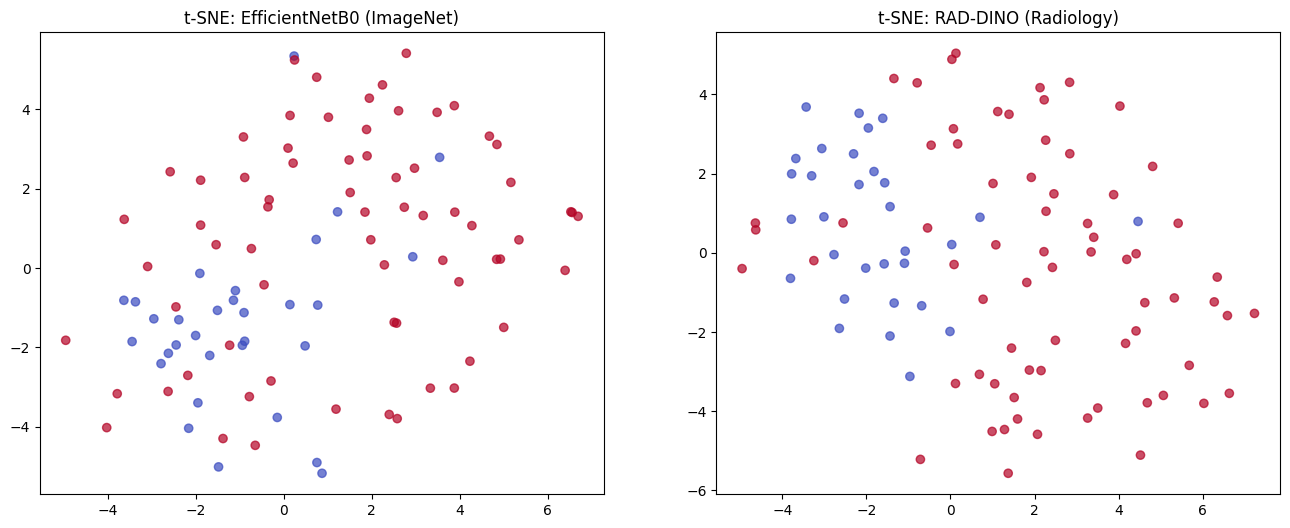

In [120]:
import torch.nn as nn
from torchvision import transforms
from PIL import Image
from sklearn.manifold import TSNE
from transformers import AutoModel

# 1. Preparação dos Modelos
print("Carregando backbones...")
eff_backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0).to(DEVICE)
dino_backbone = AutoModel.from_pretrained("microsoft/rad-dino", trust_remote_code=True).to(DEVICE)

eff_backbone.eval()
dino_backbone.eval()

for p in eff_backbone.parameters(): p.requires_grad = False
for p in dino_backbone.parameters(): p.requires_grad = False

# 2. Transforms específicos
eff_transform = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_all_features(x_data):
    emb_eff, emb_dino = [], []

    for i in tqdm(range(len(x_data)), desc="Extraindo Features"):
        img_np = x_data[i] # Já está 0-1
        img_t = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            # EfficientNet Path
            feat_eff = eff_backbone(eff_transform(img_t))
            emb_eff.append(feat_eff.cpu().numpy())

            # RAD-DINO Path (via PIL)
            img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
            inputs_dino = transforms.ToTensor()(img_pil).unsqueeze(0).to(DEVICE)
            outputs_dino = dino_backbone(inputs_dino)
            feat_dino = outputs_dino.last_hidden_state[:, 0, :] # CLS Token
            emb_dino.append(feat_dino.cpu().numpy())

    return np.vstack(emb_eff), np.vstack(emb_dino)

print("Processando conjunto de Treino...")
emb_train_eff, emb_train_dino = extract_all_features(x_train)
print("Processando conjunto de Validação...")
emb_val_eff, emb_val_dino = extract_all_features(x_val)
print("Processando conjunto de Teste...")
emb_test_eff, emb_test_dino = extract_all_features(x_test)

# 3. t-SNE e Visualização
def plot_tsne(emb, labels, title, ax):
    tsne = TSNE(n_components=2, random_state=SEED)
    vis = tsne.fit_transform(emb)
    scatter = ax.scatter(vis[:, 0], vis[:, 1], c=labels.flatten(), cmap='coolwarm', alpha=0.7)
    ax.set_title(title)
    return scatter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plot_tsne(emb_test_eff, y_test, "t-SNE: EfficientNetB0 (ImageNet)", ax1)
plot_tsne(emb_test_dino, y_test, "t-SNE: RAD-DINO (Radiology)", ax2)
plt.show()

## Prompt Card 3: Classificador 1 - EfficientNetB0 (ImageNet)

Agora treinamos uma cabeça classificadora sobre os embeddings extraídos pelo backbone pré-treinado no ImageNet.

,accuracy,auc,sensitivity,specificity,ppv,npv
model_name,,,,,,
EfficientNetB0 (ImageNet),0.95,0.984105,0.942029,0.967742,0.984848,0.882353


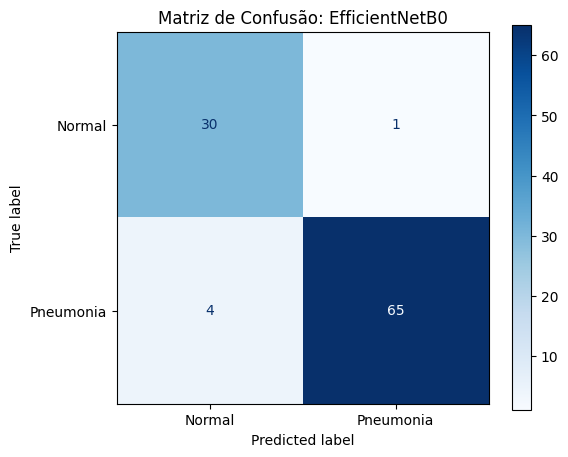

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay
import pandas as pd

# 1. Treinamento do Classificador (Logistic Regression atua como a cabeça)
clf_eff = LogisticRegression(max_iter=1000, random_state=SEED)
clf_eff.fit(emb_train_eff, y_train.flatten())

# 2. Predições no Teste
y_pred_eff = clf_eff.predict(emb_test_eff)
y_probs_eff = clf_eff.predict_proba(emb_test_eff)[:, 1]

# 3. Cálculo de Métricas Clínicas
cm_eff = confusion_matrix(y_test.flatten(), y_pred_eff)
tn, fp, fn, tp = cm_eff.ravel()

metrics_eff = {
    'model_name': 'EfficientNetB0 (ImageNet)',
    'accuracy': accuracy_score(y_test.flatten(), y_pred_eff),
    'auc': roc_auc_score(y_test.flatten(), y_probs_eff),
    'sensitivity': tp / (tp + fn),
    'specificity': tn / (tn + fp),
    'ppv': tp / (tp + fp),
    'npv': tn / (tn + fn)
}

# 4. Exibição dos Resultados
df_eff = pd.DataFrame([metrics_eff]).set_index('model_name')
display(df_eff)

# 5. Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_eff, display_labels=['Normal', 'Pneumonia'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title("Matriz de Confusão: EfficientNetB0")
plt.show()

## Prompt Card 4: Classificador 2 - RAD-DINO (Radiology)

Nesta etapa, treinamos uma rede neural simples (cabeça classificadora) sobre os embeddings do RAD-DINO, garantindo paridade experimental com o modelo anterior para uma comparação justa.

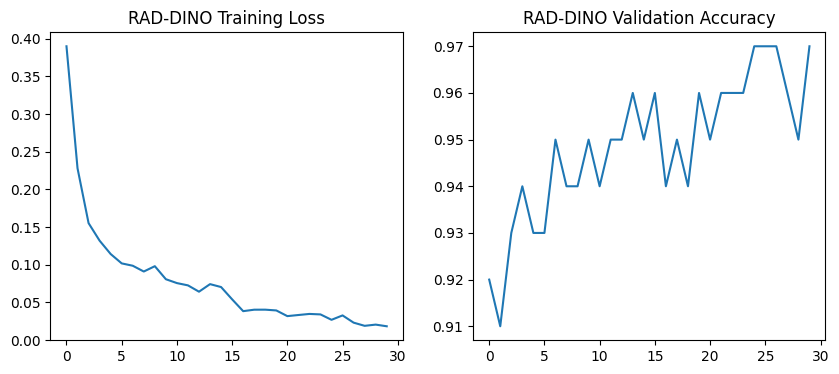

,accuracy,auc,sensitivity,specificity,ppv,npv
model_name,,,,,,
RAD-DINO (Radiology),0.95,0.987845,0.927536,1.0,1.0,0.861111


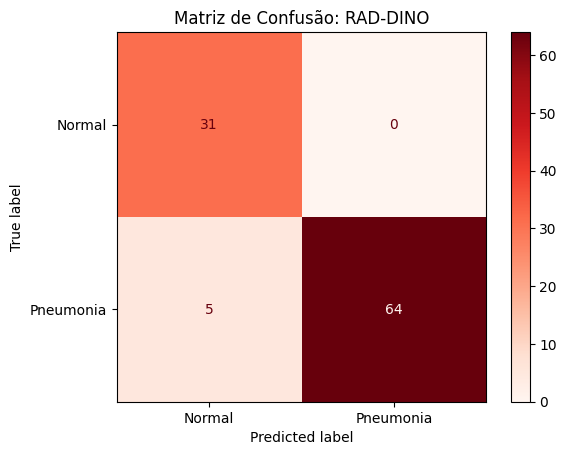

In [122]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Preparação dos DataLoaders para os Embeddings
def prepare_loader(emb, y, batch_size=32, shuffle=True):
    dataset = TensorDataset(torch.from_numpy(emb).float(), torch.from_numpy(y.flatten()).long())
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader_dino = prepare_loader(emb_train_dino, y_train)
val_loader_dino = prepare_loader(emb_val_dino, y_val, shuffle=False)
test_loader_dino = prepare_loader(emb_test_dino, y_test, shuffle=False)

# 2. Definição da Cabeça Classificadora (MLP simples para paridade)
class ClassifierHead(nn.Module):
    def __init__(self, input_dim):
        super(ClassifierHead, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )
    def forward(self, x): return self.net(x)

model_dino = ClassifierHead(emb_train_dino.shape[1]).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dino.parameters(), lr=0.001)

# 3. Loop de Treinamento
history_dino = {'loss': [], 'val_acc': []}
epochs = 30

for epoch in range(epochs):
    model_dino.train()
    total_loss = 0
    for batch_x, batch_y in train_loader_dino:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model_dino(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validação simples
    model_dino.eval()
    correct = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader_dino:
            batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
            preds = model_dino(batch_x).argmax(1)
            correct += (preds == batch_y).sum().item()

    history_dino['loss'].append(total_loss/len(train_loader_dino))
    history_dino['val_acc'].append(correct/len(y_val))

# 4. Plot das Curvas de Treino
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history_dino['loss']); plt.title('RAD-DINO Training Loss')
plt.subplot(1, 2, 2); plt.plot(history_dino['val_acc']); plt.title('RAD-DINO Validation Accuracy')
plt.show()

# 5. Avaliação Final e Métricas
model_dino.eval()
all_preds, all_probs = [], []
with torch.no_grad():
    for batch_x, _ in test_loader_dino:
        outputs = model_dino(batch_x.to(DEVICE))
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_probs.extend(torch.softmax(outputs, dim=1)[:, 1].cpu().numpy())

cm_dino = confusion_matrix(y_test.flatten(), all_preds)
tn, fp, fn, tp = cm_dino.ravel()

metrics_dino = {
    'model_name': 'RAD-DINO (Radiology)',
    'accuracy': accuracy_score(y_test.flatten(), all_preds),
    'auc': roc_auc_score(y_test.flatten(), all_probs),
    'sensitivity': tp / (tp + fn),
    'specificity': tn / (tn + fp),
    'ppv': tp / (tp + fp),
    'npv': tn / (tn + fn)
}

display(pd.DataFrame([metrics_dino]).set_index('model_name'))
ConfusionMatrixDisplay(cm_dino, display_labels=['Normal', 'Pneumonia']).plot(cmap='Reds')
plt.title("Matriz de Confusão: RAD-DINO")
plt.show()